# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings



In [2]:
# Import the libraries you will be using for analysis
#Install numpy as asked in this file (recommended)
!pip install numpy==1.26.4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_parquet('/content/drive/MyDrive/Assignments/NYC_Taxi_Records/Datasets and Dictionary/trip_records/2023-1.parquet')
#checking info and some row entries
df.info()
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  floa

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [5]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
path='/content/drive/MyDrive/Assignments/NYC_Taxi_Records/Datasets and Dictionary/trip_records/'

In [7]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir(path)

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)
        # Print current file name to check if its iteration all files
        print(f"Processing {file_name}")


        # Reading the current file
        month_df = pd.read_parquet(file_path)
        month_df['tpep_pickup_datetime']=pd.to_datetime(month_df['tpep_pickup_datetime'])
        month_df['pickup_dt']=month_df['tpep_pickup_datetime'].dt.date
        month_df['pickup_time']=month_df['tpep_pickup_datetime'].dt.hour

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in month_df['pickup_dt'].unique():
            # Iterate through each hour of the selected date
            daily_data = pd.DataFrame()
            print(f"Processing {file_name} -> {date}")
            curr_date=month_df[month_df['pickup_dt']==date]
            for hour in range(24):
              hour_data=curr_date[curr_date['pickup_time']==hour]
              sample = hour_data.sample(frac = 0.05, random_state = 42)
              # Sample 5% of the hourly data randomly
              # add data of this hour to the dataframe
              daily_data = pd.concat([daily_data, sample])
            sampled_data = pd.concat([sampled_data, daily_data])
        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data])# we initialised this empty DF earlier

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

Processing 2023-1.parquet
Processing 2023-1.parquet -> 2023-01-01
Processing 2023-1.parquet -> 2022-12-31
Processing 2023-1.parquet -> 2022-10-24
Processing 2023-1.parquet -> 2022-10-25
Processing 2023-1.parquet -> 2023-01-02
Processing 2023-1.parquet -> 2023-01-03
Processing 2023-1.parquet -> 2008-12-31
Processing 2023-1.parquet -> 2023-01-04
Processing 2023-1.parquet -> 2023-01-05
Processing 2023-1.parquet -> 2023-01-06
Processing 2023-1.parquet -> 2023-01-07
Processing 2023-1.parquet -> 2023-01-08
Processing 2023-1.parquet -> 2023-01-09
Processing 2023-1.parquet -> 2023-01-10
Processing 2023-1.parquet -> 2023-01-11
Processing 2023-1.parquet -> 2023-01-12
Processing 2023-1.parquet -> 2023-01-13
Processing 2023-1.parquet -> 2023-01-14
Processing 2023-1.parquet -> 2023-01-15
Processing 2023-1.parquet -> 2023-01-16
Processing 2023-1.parquet -> 2023-01-17
Processing 2023-1.parquet -> 2023-01-18
Processing 2023-1.parquet -> 2023-01-19
Processing 2023-1.parquet -> 2023-01-20
Processing 202

In [8]:
parFilePath=path+'final_Sampled_Data_new1.paraquet'

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [9]:
# Store the df in csv/parquet
# df.to_csv('')
# df.to_parquet('')
df.to_parquet(parFilePath,index=False)

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [10]:
# Load the new data file
#Load csv
#Load paraquet
#parFilePath=path+'final_Sampled_Data_new1.paraquet'
df=pd.read_parquet(parFilePath)

In [12]:
# df.head()
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_dt,pickup_time,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,...,0.5,5.93,0.0,1.0,35.57,NaN,NaN,2023-01-01,0,NaN


In [13]:
# df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [14]:
# Fix the index and drop any columns that are not needed
df=df.reset_index(drop=True)
#drop columns and ignore any errors
df=df.drop(columns=['pickup_dt','pickup_time'],errors='ignore')
#Checking info and some head entries
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [15]:
# Combine the two airport fee columns
df['Airport_fee'] = df[['Airport_fee', 'airport_fee']].bfill(axis=1).iloc[:, 0]
df = df.drop(columns=['airport_fee'])
#Checking info and some head entries
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [16]:
# check where values of fare amount are negative
# No negative fare amount data in sampled data
df[df['fare_amount'] < 0.0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee


Did you notice something different in the `RatecodeID` column for above records?

In [17]:
# Analyse RatecodeID for the negative fare amounts
# Since no negative fare amount data in sampled data, RatecodeID cannot be analyzed


In [18]:
# Find which columns have negative values
for col in df.select_dtypes(include='number').columns:
  if (df[col] < 0).any():
    print(col)



extra
mta_tax
improvement_surcharge
total_amount
congestion_surcharge
Airport_fee


In [19]:
# fix these negative values
#below columns came up having negative values
negative_cols=['extra','mta_tax','improvement_surcharge','total_amount','congestion_surcharge','Airport_fee']
for col in negative_cols:
  #keeping NAN entries and removing negatives
  df = df[(df[col] >= 0) | (df[col].isna())]

In [20]:
(df.select_dtypes(include='number') < 0).sum()

,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
extra,0
mta_tax,0


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [21]:
# Find the proportion of missing values in each column
missing_prop = (df.isna().mean() * 100).round(2)
missing_prop.sort_values(ascending=False)

,0
Airport_fee,3.42
congestion_surcharge,3.42
passenger_count,3.42
RatecodeID,3.42
store_and_fwd_flag,3.42
extra,0.00
total_amount,0.00
improvement_surcharge,0.00
tolls_amount,0.00
tip_amount,0.00


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [23]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
df[df.isna().any(axis=1)].head()
#Median is the best choice for passenger count
median_passenger_ct = df['passenger_count'].median()
df['passenger_count'] = df['passenger_count'].fillna(median_passenger_ct)



Did you find zeroes in passenger_count? Handle these.

In [25]:
#Handling zeroes in passenger_count
(df['passenger_count'] == 0).sum()
df.loc[df['passenger_count'] == 0, 'passenger_count'] = pd.NA
median_pc = df['passenger_count'].median()
df['passenger_count'] = df['passenger_count'].fillna(median_pc)

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [27]:
# Fix missing values in 'RatecodeID'
# mode is the best choice for rate code as it will assign the most frequent values (categorical code)
df['RatecodeID'].isna().sum()
ratecode_mode = df['RatecodeID'].mode()[0]
df['RatecodeID'] = df['RatecodeID'].fillna(ratecode_mode)


In [28]:
df['RatecodeID'].isna().sum()

0

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [29]:
# handle null values in congestion_surcharge
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [30]:
# Handle any remaining missing values
#df.isna().sum()
#Categorical so mode for store and fwd flag
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0])
#Filling congestion surcharge and airport fee as 0
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)
df['Airport_fee'] = df['Airport_fee'].fillna(0)
df.isna().sum()


,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [31]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df.describe()
#df[['trip_distance', 'fare_amount']].describe()
#df.select_dtypes(include='number').describe()
#df['passenger_count'].value_counts().sort_index()
#df['trip_distance'].describe()
#df['fare_amount'].describe()
#df['total_amount'].describe()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,1.896321e+06,1896321,1896321,1.896321e+06,1.896321e+06,1.896321e+06,1.896321e+06,1.896321e+06,1.896321e+06,1.896321e+06,1.896321e+06,1.896321e+06,1.896321e+06,1.896321e+06,1.896321e+06,1.896321e+06,1.896321e+06,1.896321e+06
mean,1.733015e+00,2023-07-02 19:59:00.671689,2023-07-02 20:16:26.662164,1.372231e+00,3.858258e+00,1.612985e+00,1.652818e+02,1.640515e+02,1.163780e+00,1.992018e+01,1.588086e+00,4.953195e-01,3.547158e+00,5.965587e-01,9.990529e-01,2.898322e+01,2.228753e+00,1.380278e-01
min,1.000000e+00,2022-12-31 23:51:30,2022-12-31 23:56:06,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2023-04-02 16:09:03,2023-04-02 16:27:09,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2023-06-27 15:43:16,2023-06-27 16:00:27,1.000000e+00,1.800000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2023-10-06 19:36:18,2023-10-06 19:53:02,1.000000e+00,3.400000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.420000e+00,0.000000e+00,1.000000e+00,3.094000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2023-12-31 23:57:51,2024-01-01 20:50:55,9.000000e+00,1.263605e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.431635e+05,2.080000e+01,4.000000e+00,2.230800e+02,1.430000e+02,1.000000e+00,1.431675e+05,2.500000e+00,1.750000e+00
std,4.476461e-01,NaN,NaN,8.643989e-01,1.294112e+02,7.267410e+00,6.400058e+01,6.980194e+01,5.081096e-01,1.055392e+02,1.829206e+00,4.845241e-02,4.054902e+00,2.187920e+00,2.835794e-02,1.064182e+02,7.775236e-01,4.575714e-01


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [32]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6]

In [33]:
#Checking passenger count >6 has been removed
df['passenger_count'].value_counts().sort_index()

,count
passenger_count,
1.0,1471723
2.0,277283
3.0,69032
4.0,38532
5.0,23871
6.0,15859


In [34]:
# Continue with outlier handling
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))]
df = df[df['trip_distance'] <= 250]
df = df[df['payment_type'] != 0]



In [35]:
# Do any columns need standardising?
# No column need any more standardising
df.head()



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.4,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.9,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.4,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.5,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00
5,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,7.10,1.0,N,246,37,1,34.5,3.5,0.5,7.90,0.0,1.0,47.40,2.5,0.00


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [36]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Temporal (Neither Numerical nor Categorical)
* `tpep_dropoff_datetime`: Temporal (Neither Numerical nor Categorical)
* `passenger_count`: Numerical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`: Numerical
* `trip_duration`: Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`: Numerical
* `extra`: Numerical
* `mta_tax`: Numerical
* `tip_amount`: Numerical
* `tolls_amount`: Numerical
* `improvement_surcharge`: Numerical
* `total_amount`: Numerical
* `congestion_surcharge`: Numerical
* `airport_fee`: Numerical

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

<Axes: title={'center': 'Hourly Taxi Pickups'}, xlabel='pickup_hour'>

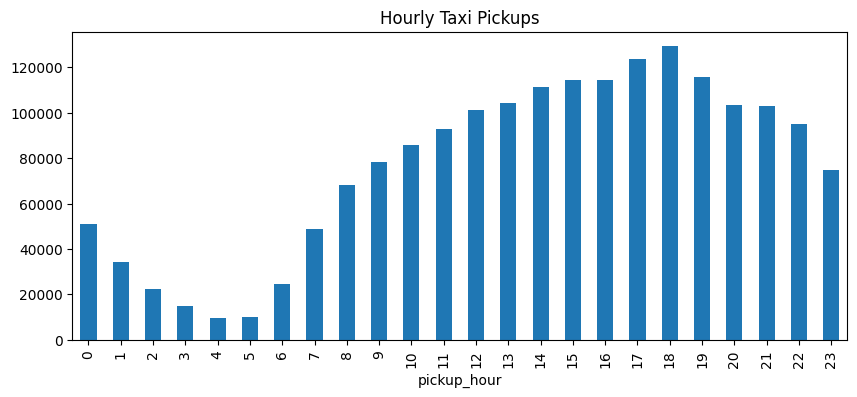

In [37]:
# Find and show the hourly trends in taxi pickups
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
hourlyTrips = df['pickup_hour'].value_counts().sort_index()
hourlyTrips
hourlyTrips.plot(kind='bar', figsize=(10,4), title='Hourly Taxi Pickups')


<Axes: title={'center': 'Daily Taxi Pickups'}, xlabel='pickup_day'>

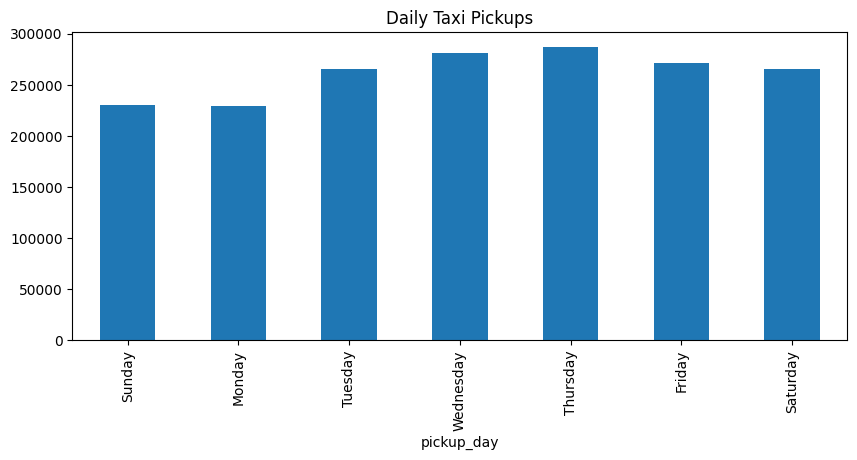

In [38]:
# Find and show the daily trends in taxi pickups (days of the week)
daywiseOrder=['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
df['pickup_day']=df['tpep_pickup_datetime'].dt.day_name()
dailyTrips=df['pickup_day'].value_counts().reindex(daywiseOrder)
dailyTrips
dailyTrips.plot(kind='bar', figsize=(10,4), title='Daily Taxi Pickups')

<Axes: title={'center': 'Monthly Taxi Pickups'}, xlabel='pickup_month'>

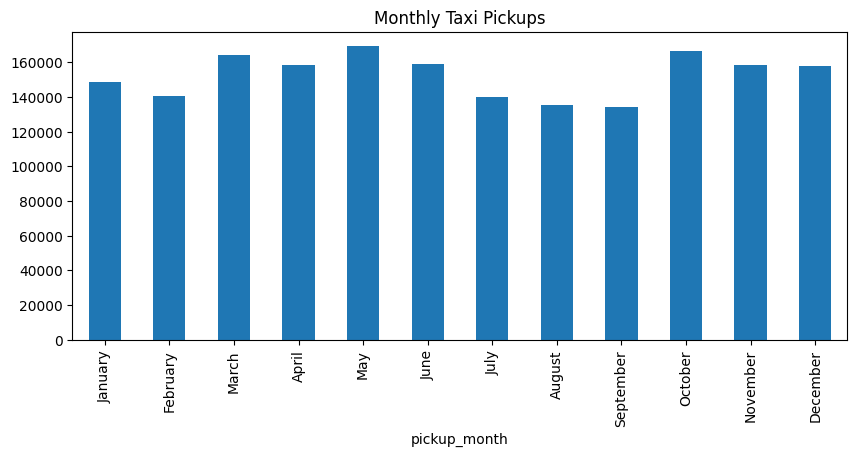

In [39]:
# Show the monthly trends in pickups
monthOrder = ['January','February','March','April','May','June','July','August','September','October','November','December']
df['pickup_month']=df['tpep_pickup_datetime'].dt.month_name()
monthlyTrips=df['pickup_month'].value_counts().reindex(monthOrder)
monthlyTrips
monthlyTrips.plot(kind='bar', figsize=(10,4), title='Monthly Taxi Pickups')


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

***Answer: No negative values, as we had removed it at the start. Yes we have 0 values.***

In [40]:
# Analyse the above parameters
#Negative value check
(df[['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']]<0).sum()
#No negative Values as we had removed it at the start while cleaning

,0
fare_amount,0
tip_amount,0
total_amount,0
trip_distance,0


In [41]:
#Zero value check, yes zero values
(df[['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']] == 0).sum()


,0
fare_amount,501
tip_amount,410159
total_amount,255
trip_distance,22911


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

***Answer: No, removing all zero values would not be right, as in the case of tip_amount zero values can represent real scenarios and also trips within the same pickup and dropoff zone, so it may create a some change in understanding data analysis***

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

***Answer: No***

In [42]:
# Create a df with non zero entries for the selected parameters.
# Remove fare_amount=0 and total_amount=0 and not removing tip_amount=0 and trip_distance=0 as they seem valid
non_zero_df=(df[(df['fare_amount']>0) & (df['total_amount'])>0]).copy()
(non_zero_df[['fare_amount', 'total_amount']] == 0).sum()


,0
fare_amount,0
total_amount,0


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

<Axes: title={'center': 'Monthly Revenue'}, xlabel='pickup_month'>

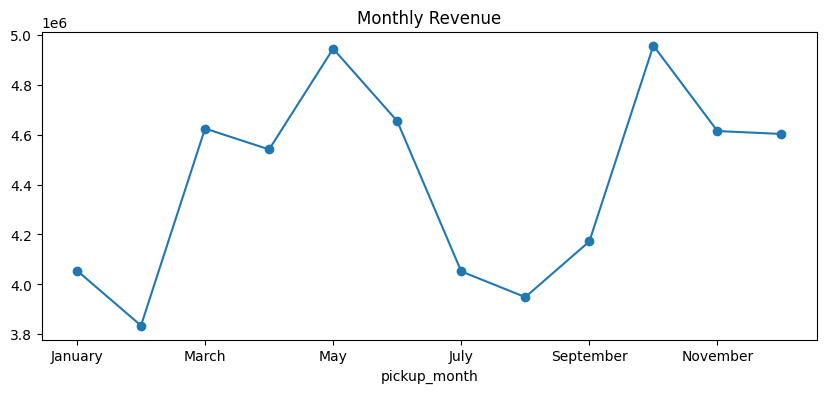

In [43]:
# Group data by month and analyse monthly revenue

non_zero_df['pickup_month']=non_zero_df['tpep_pickup_datetime'].dt.month_name()
monthly_rev = non_zero_df.groupby('pickup_month')['total_amount'].sum().reindex([
    'January','February','March','April','May','June','July','August','September',
    'October','November','December'
      ])
monthly_rev.plot(kind='line',marker='o',figsize=(10,4),title='Monthly Revenue')

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [44]:
# Calculate proportion of each quarter

non_zero_df['quarter']=non_zero_df['tpep_pickup_datetime'].dt.quarter
quarter_rev=non_zero_df.groupby('quarter')['total_amount'].sum()
total_rev=non_zero_df['total_amount'].sum()
(quarter_rev/total_rev*100).round(2)

,total_amount
quarter,
1,23.61
2,26.68
3,22.97
4,26.74


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

<Axes: title={'center': 'Relationship between Trip Distance and Fare Amount'}, xlabel='trip_distance', ylabel='fare_amount'>

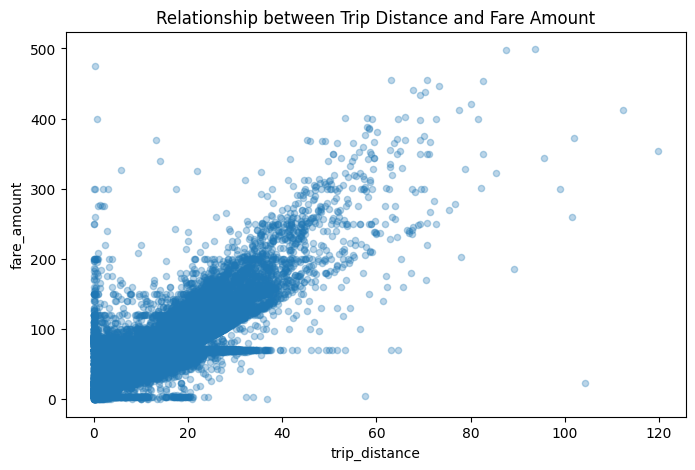

In [45]:
# Show how trip fare is affected by distance
new_df=non_zero_df[non_zero_df['trip_distance'] > 0].copy()
new_df_filtered = new_df[(new_df['fare_amount'] < 500)&(new_df['trip_distance'] < 125)].copy()
new_df_filtered.plot(
    kind='scatter',
    x='trip_distance',
    y='fare_amount',
    alpha=0.3,
    figsize=(8,5),
    title='Relationship between Trip Distance and Fare Amount'
)

In [46]:
#Correlation
correlation_tf_fa = new_df_filtered['trip_distance'].corr(new_df_filtered['fare_amount'])
correlation_tf_fa


0.9453102963727374

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [47]:
# Show relationship between fare and trip duration
new_df['trip_duration']=((new_df['tpep_dropoff_datetime']-new_df['tpep_pickup_datetime']).dt.total_seconds() / 60)
new_df_filtered_fa_td = new_df[(new_df['fare_amount'] < 500)&(new_df['trip_duration'] < 200)].copy()
correlation_fa_td = new_df_filtered_fa_td['fare_amount'].corr(new_df_filtered_fa_td['trip_duration'])
correlation_fa_td


0.8454730727511235

<Axes: title={'center': 'Fare Amount vs Trip Duration'}, xlabel='trip_duration', ylabel='fare_amount'>

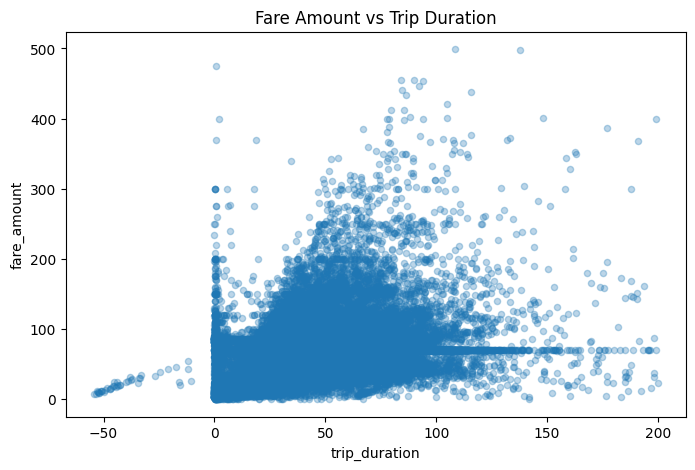

In [48]:
new_df_filtered_fa_td.plot(
    kind='scatter',
    x='trip_duration',
    y='fare_amount',
    alpha=0.3,
    figsize=(8,5),
    title='Fare Amount vs Trip Duration'
)


In [53]:
# Show relationship between fare and number of passengers
new_df_filtered_fa_pc = new_df[(new_df['fare_amount'] < 500)&(new_df['trip_duration'] < 200)].copy()
correlation_fa_pc = new_df_filtered_fa_pc['fare_amount'].corr(new_df_filtered_fa_pc['passenger_count'])
correlation_fa_pc



0.0426898371288095

<Axes: title={'center': 'Fare Amount vs Passenger count'}, xlabel='passenger_count', ylabel='fare_amount'>

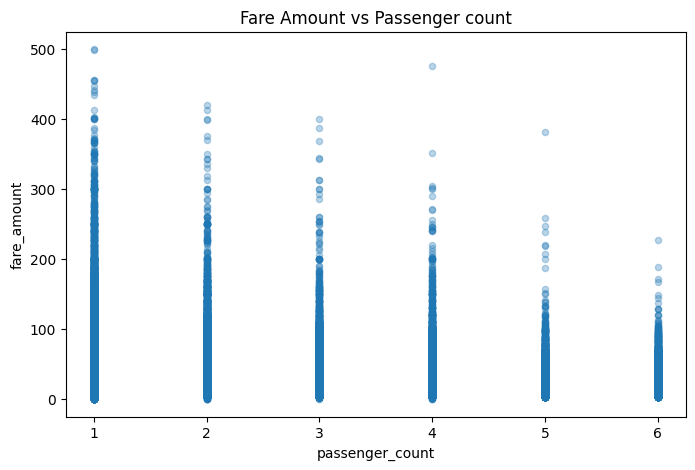

In [54]:
new_df_filtered_fa_pc.plot(
    kind='scatter',
    x='passenger_count',
    y='fare_amount',
    alpha=0.3,
    figsize=(8,5),
    title='Fare Amount vs Passenger count'
)

In [57]:
# Show relationship between tip and trip distance
correlation_ta_td = new_df['tip_amount'].corr(new_df['trip_distance'])
correlation_ta_td



0.5865736595406826

<Axes: title={'center': 'Tip vs Trip distance'}, xlabel='trip_distance', ylabel='tip_amount'>

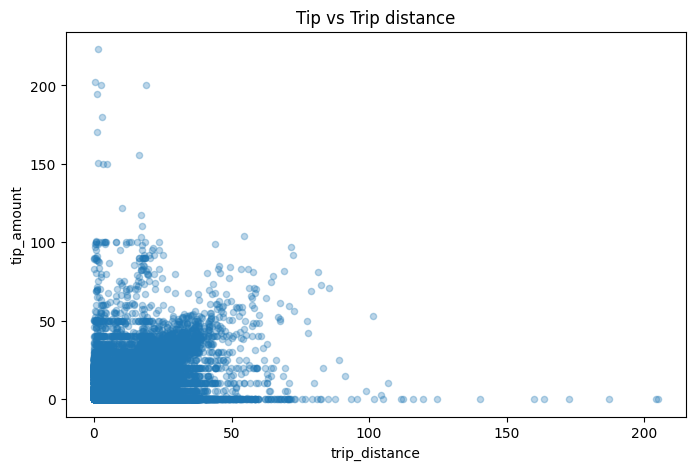

In [56]:
new_df.plot(
    kind='scatter',
    x='trip_distance',
    y='tip_amount',
    alpha=0.3,
    figsize=(8,5),
    title='Tip vs Trip distance'
)

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

,proportion
payment_type,
1,81.49
2,17.27
3,0.49
4,0.75


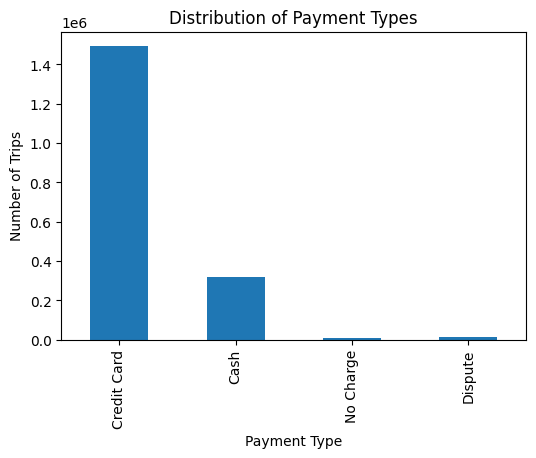

In [58]:
# Analyse the distribution of different payment types (payment_type).

payment_dist = df['payment_type'].value_counts().sort_index()
payment_prop = (df['payment_type'].value_counts(normalize=True).sort_index() * 100).round(2)
payment_dist.index = ['Credit Card', 'Cash', 'No Charge', 'Dispute']
payment_dist.plot(
    kind='bar',
    figsize=(6,4),
    title='Distribution of Payment Types',
    xlabel='Payment Type',
    ylabel='Number of Trips'
)
payment_dist
payment_prop




- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [61]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [62]:
import geopandas as gpd


# Read the shapefile using geopandas
taxi_zones_path='/content/drive/MyDrive/Assignments/NYC_Taxi_Records/Datasets and Dictionary/taxi_zones/'
zones = gpd.read_file(taxi_zones_path+'taxi_zones.shp')# read the .shp file using gpd
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

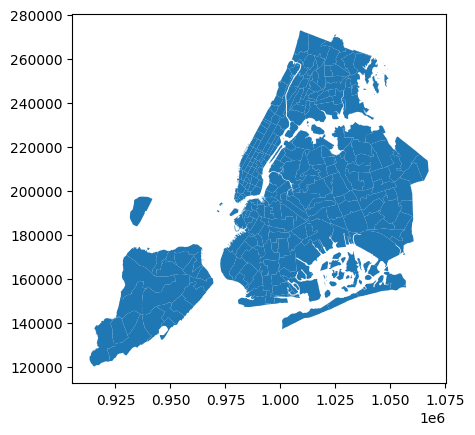

In [63]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [64]:
# Merge zones and trip records using locationID and PULocationID
#pickup_zones = zones[['LocationID', 'zone', 'borough', 'geometry','Shape_Leng','Shape_Area']]
merged_trip_zones = df.merge(
    zones,
    how='left',
    left_on='PULocationID',
    right_on='LocationID'
)
merged_trip_zones.head()
#merged_trip_zones = merged_trip_zones.drop(columns=['LocationID'])

#merged_trip_zones['zone'].isna().sum()
#merged_trip_zones.loc[merged_trip_zones['zone'].isna(),'PULocationID'].unique()




,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_hour,pickup_day,pickup_month,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0,Sunday,January,138.0,0.107467,0.000537,LaGuardia Airport,138.0,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031..."
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0,Sunday,January,161.0,0.035804,0.000072,Midtown Center,161.0,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21..."
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0,Sunday,January,237.0,0.042213,0.000096,Upper East Side South,237.0,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21..."
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0,Sunday,January,143.0,0.054180,0.000151,Lincoln Square West,143.0,Manhattan,"POLYGON ((989338.1 223572.253, 989368.225 2235..."
4,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,7.10,1.0,N,246,37,1,...,0,Sunday,January,246.0,0.069467,0.000281,West Chelsea/Hudson Yards,246.0,Manhattan,"POLYGON ((983031.177 217138.506, 983640.32 216..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [65]:
# Group data by location and calculate the number of trips

trips_grouped_by_loc = merged_trip_zones.groupby('PULocationID').size().reset_index(name='tripCount')
trips_grouped_by_loc.head()


,PULocationID,tripCount
0,1,214
1,2,2
2,3,40
3,4,1861
4,5,13


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [66]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trip_counts = zones.merge(
    trips_grouped_by_loc,
    how='left',
    left_on='LocationID',
    right_on='PULocationID'
)
zones_with_trip_counts['tripCount'] = zones_with_trip_counts['tripCount'].fillna(0)
zones_with_trip_counts['tripCount'] = zones_with_trip_counts['tripCount'].astype('Int64')
zones_with_trip_counts['PULocationID'] = zones_with_trip_counts['PULocationID'].astype('Int64')
zones_with_trip_counts.head()




,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,tripCount
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1,214
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2,2
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3,40
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4,1861
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5,13


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

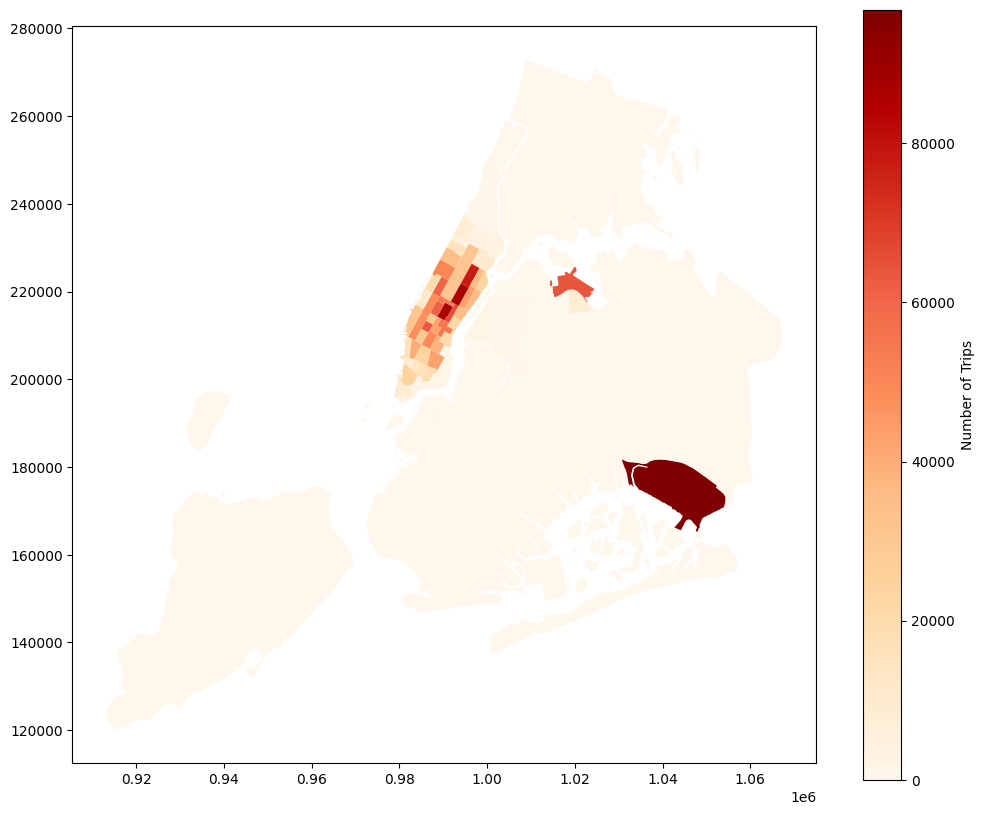

In [67]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it
zones_with_trip_counts.plot(
    column='tripCount',
    ax=ax,
    cmap='OrRd',
    legend=True,
    legend_kwds={'label': "Number of Trips",'orientation': "vertical"})
plt.show()



In [68]:
# can you try displaying the zones DF sorted by the number of trips?
zones_with_trip_counts.sort_values(
    by='tripCount',
    ascending=False
)[['LocationID', 'zone', 'borough', 'tripCount']].head()



,LocationID,zone,borough,tripCount
131,132,JFK Airport,Queens,96815
236,237,Upper East Side South,Manhattan,86903
160,161,Midtown Center,Manhattan,85944
235,236,Upper East Side North,Manhattan,77514
161,162,Midtown East,Manhattan,65633


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [69]:
# Find routes which have the slowest speeds at different times of the day
df['pickupHr'] = df['tpep_pickup_datetime'].dt.hour
df['trip_duration_hours'] = ((df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 3600)
df_speed = df[
    (df['trip_distance'] > 0) &
    (df['trip_duration_hours'] > 0) &
    (df['trip_duration_hours'] < 3)
].copy()
route_speed = df_speed.groupby(
    ['PULocationID', 'DOLocationID', 'pickupHr']
).agg(
    avg_distance=('trip_distance', 'mean'),
    avg_duration=('trip_duration_hours', 'mean'),
    trip_count=('trip_distance', 'size')
).reset_index()
route_speed['avg_speed_mph'] = (
    route_speed['avg_distance'] / route_speed['avg_duration']
)
slow_routes = route_speed.sort_values(by='avg_speed_mph')
slow_routes.head(10)



,PULocationID,DOLocationID,pickupHr,avg_distance,avg_duration,trip_count,avg_speed_mph
120340,258,258,1,0.02,0.762500,1,0.026230
89170,194,194,16,0.01,0.204444,1,0.048913
9698,45,45,10,0.05,0.840556,1,0.059484
42431,124,129,12,0.10,1.388333,1,0.072029
49924,134,265,15,0.10,1.354444,1,0.073831
16761,67,215,15,0.10,1.280556,1,0.078091
23603,75,203,13,0.10,1.057222,1,0.094587
109080,237,5,15,0.10,1.052222,1,0.095037
30201,89,205,15,0.10,1.041667,1,0.096000
93647,220,236,11,0.10,1.032222,1,0.096878


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

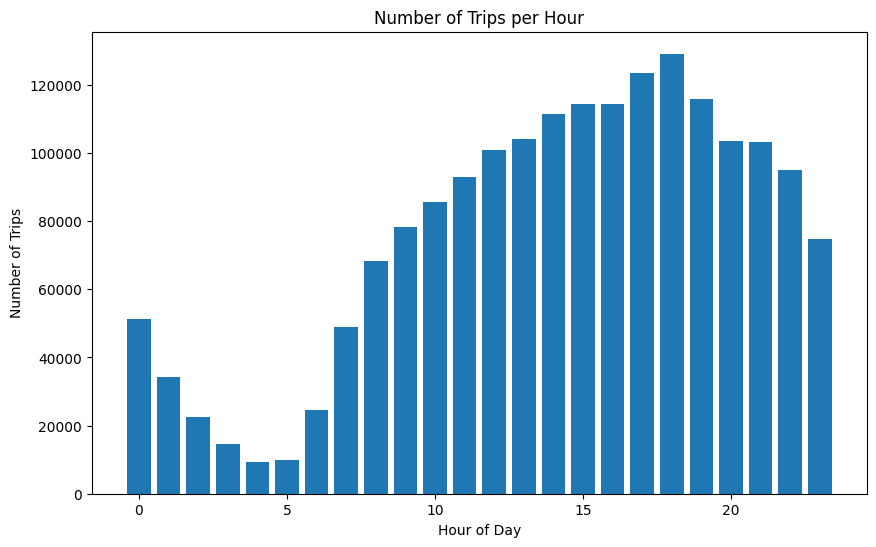

,18
pickupHr,18
trip_count,129184


In [70]:
# Visualise the number of trips per hour and find the busiest hour

#df['pickupHr'] = df['tpep_pickup_datetime'].dt.hour
trips_per_hour = df.groupby('pickupHr').size().reset_index(name='trip_count')
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(trips_per_hour['pickupHr'], trips_per_hour['trip_count'])
ax.set_title("Number of Trips per Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Trips")

plt.show()
busiest_hour = trips_per_hour.loc[
    trips_per_hour['trip_count'].idxmax()
]

busiest_hour



Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [71]:
# Scale up the number of trips
trips_per_hour = df.groupby('pickupHr').size().reset_index(name='trip_count')

top_5_hours = trips_per_hour.sort_values(
    by='trip_count',
    ascending=False
).head(5)

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction =0.05

top_5_hours['actual_trip_count'] = (
    top_5_hours['trip_count'] / sample_fraction
)

top_5_hours



,pickupHr,trip_count,actual_trip_count
18,18,129184,2583680.0
17,17,123557,2471140.0
19,19,115915,2318300.0
15,15,114292,2285840.0
16,16,114281,2285620.0


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

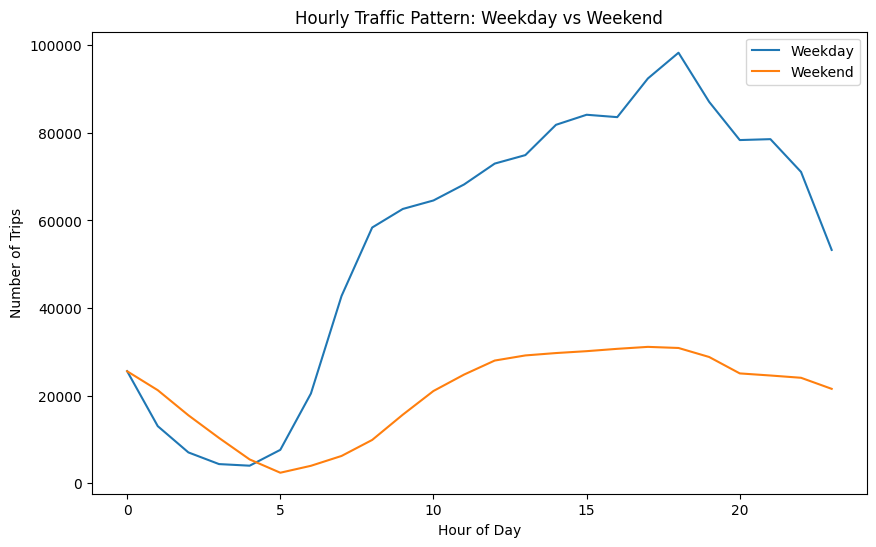

In [72]:
# Compare traffic trends for the week days and weekends
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_weekday'] = df['tpep_pickup_datetime'].dt.weekday
df['day_type'] = df['pickup_weekday'].apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)
hourly_daytype = df.groupby(
    ['day_type', 'pickupHr']
).size().reset_index(name='trip_count')
weekday_data = hourly_daytype[hourly_daytype['day_type'] == 'Weekday']
weekend_data = hourly_daytype[hourly_daytype['day_type'] == 'Weekend']
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(
    weekday_data['pickupHr'],
    weekday_data['trip_count'],
    label='Weekday'
)

ax.plot(
    weekend_data['pickupHr'],
    weekend_data['trip_count'],
    label='Weekend'
)

ax.set_title("Hourly Traffic Pattern: Weekday vs Weekend")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Trips")
ax.legend()

plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [73]:
# Find top 10 pickup and dropoff zones
top_pickup_zones = df.groupby('PULocationID').size() \
    .reset_index(name='pickup_count') \
    .sort_values(by='pickup_count', ascending=False) \
    .head(10)

top_pickup_zones


,PULocationID,pickup_count
125,132,96815
229,237,86903
154,161,85944
228,236,77514
155,162,65633
131,138,64173
178,186,63470
222,230,61314
135,142,60884
163,170,54490


In [74]:
top_dropoff_zones = df.groupby('DOLocationID').size() \
    .reset_index(name='dropoff_count') \
    .sort_values(by='dropoff_count', ascending=False) \
    .head(10)

top_dropoff_zones


,DOLocationID,dropoff_count
230,236,81269
231,237,77556
156,161,71643
224,230,56396
165,170,54311
157,162,52248
137,142,51493
233,239,51258
136,141,48448
67,68,46352


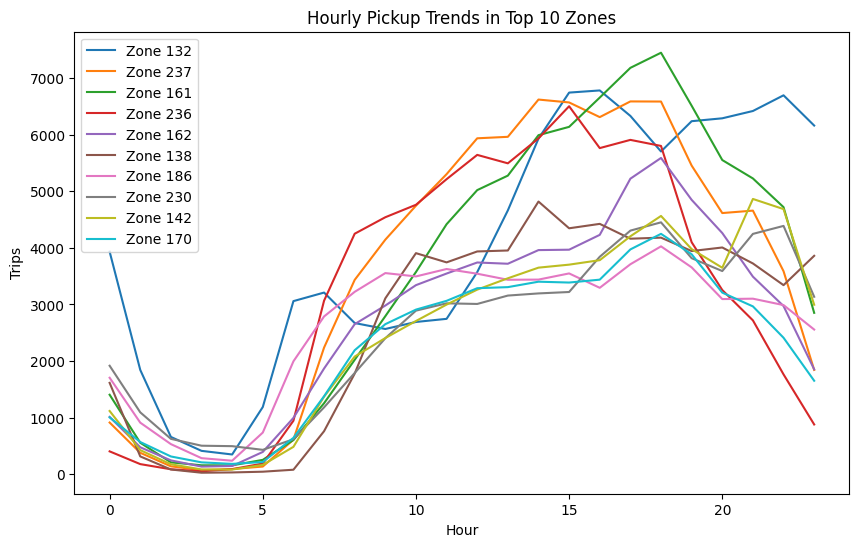

In [75]:
top_pickup_ids = top_pickup_zones['PULocationID']

pickup_hourly_trend = df[
    df['PULocationID'].isin(top_pickup_ids)
].groupby(['PULocationID', 'pickupHr']).size().reset_index(name='trip_count')
top_dropoff_ids = top_dropoff_zones['DOLocationID']

dropoff_hourly_trend = df[
    df['DOLocationID'].isin(top_dropoff_ids)
].groupby(['DOLocationID', 'pickupHr']).size().reset_index(name='trip_count')


fig, ax = plt.subplots(figsize=(10,6))

for zone in top_pickup_ids:
    zone_data = pickup_hourly_trend[pickup_hourly_trend['PULocationID'] == zone]
    ax.plot(zone_data['pickupHr'], zone_data['trip_count'], label=f'Zone {zone}')

ax.set_title("Hourly Pickup Trends in Top 10 Zones")
ax.set_xlabel("Hour")
ax.set_ylabel("Trips")
ax.legend()

plt.show()

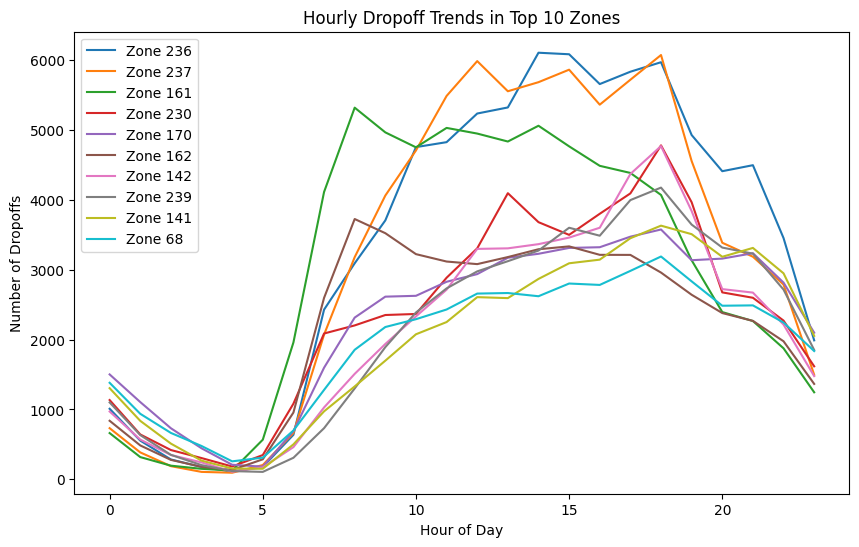

In [77]:

fig, ax = plt.subplots(figsize=(10,6))

for zone in top_dropoff_ids:
    zone_data = dropoff_hourly_trend[
        dropoff_hourly_trend['DOLocationID'] == zone
    ]
    ax.plot(
        zone_data['pickupHr'],
        zone_data['trip_count'],
        label=f'Zone {zone}'
    )

ax.set_title("Hourly Dropoff Trends in Top 10 Zones")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Dropoffs")
ax.legend()

plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [79]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_counts = df.groupby('PULocationID') \
    .size() \
    .reset_index(name='pickup_count')
dropoff_counts = df.groupby('DOLocationID') \
    .size() \
    .reset_index(name='dropoff_count')
zone_flow = pickup_counts.merge(
    dropoff_counts,
    left_on='PULocationID',
    right_on='DOLocationID',
    how='outer'
)
zone_flow['LocationID'] = zone_flow['PULocationID'].fillna(zone_flow['DOLocationID'])
zone_flow = zone_flow[['LocationID', 'pickup_count', 'dropoff_count']]
zone_flow[['pickup_count', 'dropoff_count']] = \
zone_flow[['pickup_count', 'dropoff_count']].fillna(0)
zone_flow['pickup_drop_ratio'] = zone_flow.apply(
    lambda row: row['pickup_count'] / row['dropoff_count']
    if row['dropoff_count'] > 0 else float('inf'),
    axis=1
)

top_10_ratio = zone_flow.sort_values(
    by='pickup_drop_ratio',
    ascending=False
).head(10)

top_10_ratio


,LocationID,pickup_count,dropoff_count,pickup_drop_ratio
194,199.0,2.0,0.0,inf
69,70.0,8353.0,1001.0,8.344655
127,132.0,96815.0,20961.0,4.618816
133,138.0,64173.0,22249.0,2.884309
181,186.0,63470.0,40114.0,1.582241
42,43.0,30751.0,22367.0,1.374838
109,114.0,24113.0,17539.0,1.374822
244,249.0,40404.0,30466.0,1.326200
157,162.0,65633.0,52248.0,1.256182
156,161.0,85944.0,71643.0,1.199615


In [80]:
bottom_10_ratio = zone_flow.sort_values(
    by='pickup_drop_ratio',
    ascending=True
).head(10)

bottom_10_ratio


,LocationID,pickup_count,dropoff_count,pickup_drop_ratio
171,176.0,0.0,12.0,0.000000
98,99.0,0.0,3.0,0.000000
29,30.0,0.0,18.0,0.000000
240,245.0,0.0,30.0,0.000000
26,27.0,1.0,39.0,0.025641
216,221.0,1.0,34.0,0.029412
252,257.0,29.0,758.0,0.038259
0,1.0,214.0,5318.0,0.040241
110,115.0,1.0,23.0,0.043478
193,198.0,52.0,990.0,0.052525


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [81]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
(df['pickup_hour'] >= 23) | (df['pickup_hour'] <= 5)
night_df = df[
    (df['pickup_hour'] >= 23) | (df['pickup_hour'] <= 5)
]
top_night_pickups = night_df.groupby('PULocationID') \
    .size() \
    .reset_index(name='pickup_count') \
    .sort_values(by='pickup_count', ascending=False) \
    .head(10)

top_night_pickups



,PULocationID,pickup_count
71,79,15550
114,132,14544
222,249,12472
42,48,10463
130,148,9629
99,114,8749
204,230,8206
163,186,6968
144,164,6143
60,68,6050


In [82]:
top_night_dropoffs = night_df.groupby('DOLocationID') \
    .size() \
    .reset_index(name='dropoff_count') \
    .sort_values(by='dropoff_count', ascending=False) \
    .head(10)

top_night_dropoffs



,DOLocationID,dropoff_count
77,79,8313
46,48,6874
164,170,6265
66,68,5858
102,107,5756
135,141,5272
255,263,4977
241,249,4944
222,230,4641
142,148,4382


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [83]:
# Filter for night hours (11 PM to 5 AM)
day_df = df[
    (df['pickup_hour'] > 5) & (df['pickup_hour'] < 23)
]
night_revenue = night_df['total_amount'].sum()
day_revenue = day_df['total_amount'].sum()
total_revenue = df['total_amount'].sum()
night_share = ((night_revenue / total_revenue) * 100).round(2)
day_share = ((day_revenue / total_revenue) * 100).round(2)

night_share, day_share



(12.06, 87.94)

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [84]:
# Analyse the fare per mile per passenger for different passenger counts
df_fare = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0) &
    (df['passenger_count'] > 0)
].copy()
df_fare['fare_per_mile'] = (
    df_fare['fare_amount'] / df_fare['trip_distance']
)
fare_by_passenger = df_fare.groupby('passenger_count').agg(
    avg_fare_per_mile=('fare_per_mile', 'mean')
).reset_index()
fare_by_passenger['fare_per_mile_per_passenger'] = (
    fare_by_passenger['avg_fare_per_mile'] /
    fare_by_passenger['passenger_count']
)

fare_by_passenger




,passenger_count,avg_fare_per_mile,fare_per_mile_per_passenger
0,1.0,11.012470,11.012470
1,2.0,12.864801,6.432401
2,3.0,11.724296,3.908099
3,4.0,17.452908,4.363227
4,5.0,8.548072,1.709614
5,6.0,8.104462,1.350744


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

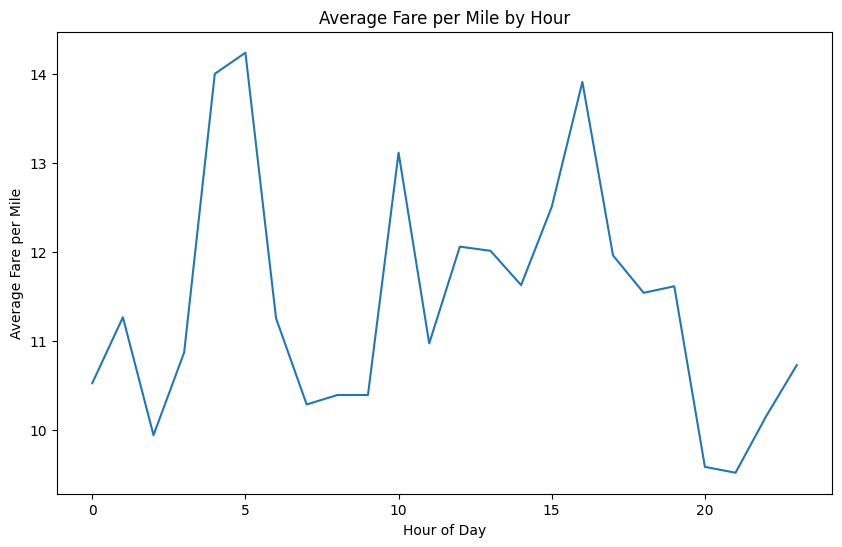

In [85]:
# Compare the average fare per mile for different days and for different times of the day
df_fare = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0)
].copy()
df_fare['fare_per_mile'] = (
    df_fare['fare_amount'] / df_fare['trip_distance']
)
fare_by_hour = df_fare.groupby('pickup_hour').agg(
    avg_fare_per_mile=('fare_per_mile', 'mean')
).reset_index()

fare_by_hour
plt.figure(figsize=(10,6))
plt.plot(fare_by_hour['pickup_hour'],
         fare_by_hour['avg_fare_per_mile'])
plt.title("Average Fare per Mile by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare per Mile")
plt.show()


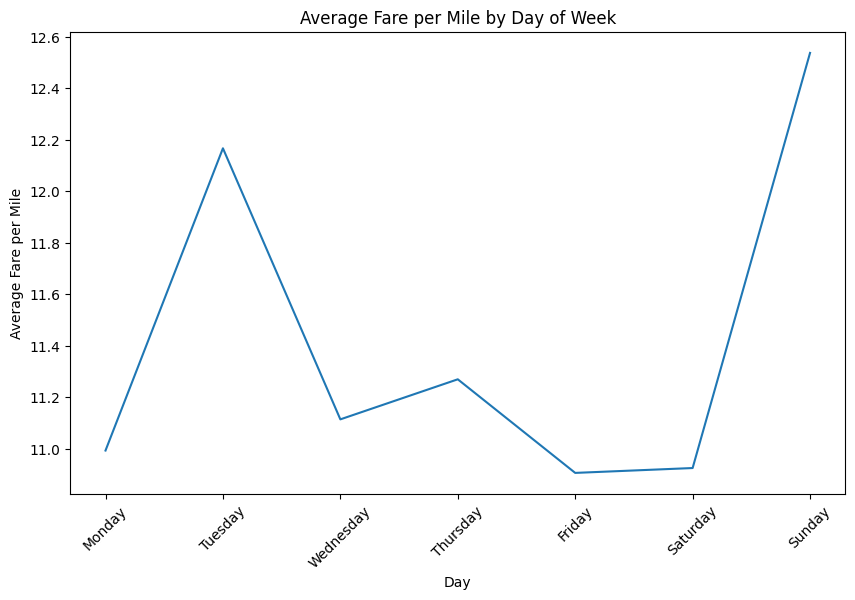

In [86]:
df_fare['pickup_day'] = df_fare['tpep_pickup_datetime'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']
fare_by_day = df_fare.groupby('pickup_day').agg(
    avg_fare_per_mile=('fare_per_mile', 'mean')
).reset_index()

fare_by_day
fare_by_day['pickup_day'] = pd.Categorical(
    fare_by_day['pickup_day'],
    categories=day_order,
    ordered=True
)

fare_by_day = fare_by_day.sort_values('pickup_day')
plt.figure(figsize=(10,6))
plt.plot(fare_by_day['pickup_day'],
         fare_by_day['avg_fare_per_mile'])
plt.title("Average Fare per Mile by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Fare per Mile")
plt.xticks(rotation=45)
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

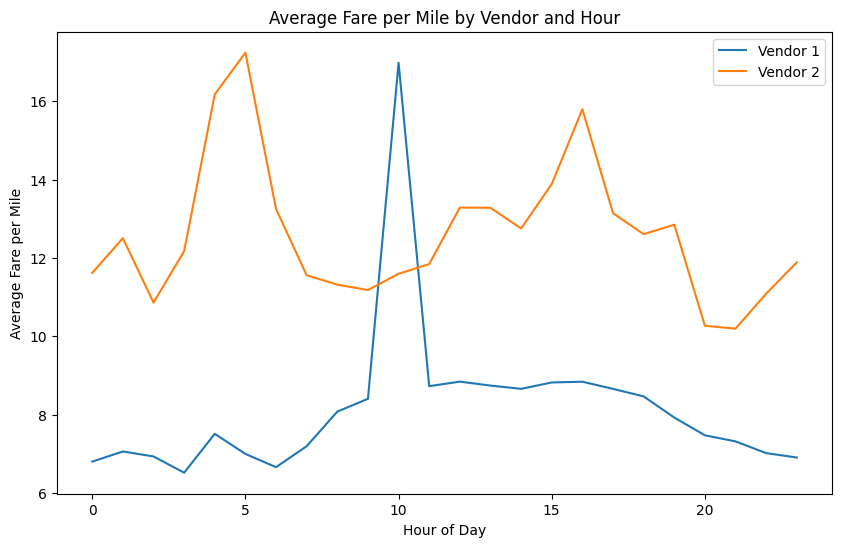

In [87]:
# Compare fare per mile for different vendors
df_vendor = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0)
].copy()
df_vendor['fare_per_mile'] = (
    df_vendor['fare_amount'] / df_vendor['trip_distance']
)
vendor_hour_fare = df_vendor.groupby(
    ['VendorID', 'pickup_hour']
).agg(
    avg_fare_per_mile=('fare_per_mile', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10,6))

for vendor in vendor_hour_fare['VendorID'].unique():
    vendor_data = vendor_hour_fare[
        vendor_hour_fare['VendorID'] == vendor
    ]

    ax.plot(
        vendor_data['pickup_hour'],
        vendor_data['avg_fare_per_mile'],
        label=f'Vendor {vendor}'
    )

ax.set_title("Average Fare per Mile by Vendor and Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Fare per Mile")
ax.legend()

plt.show()


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [88]:
# Defining distance tiers
df_tier = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0)
].copy()
df_tier['fare_per_mile'] = (
    df_tier['fare_amount'] / df_tier['trip_distance']
)
def distance_tier(distance):
    if distance <= 2:
        return 'Up to 2 miles'
    elif distance <= 5:
        return '2 to 5 miles'
    else:
        return 'More than 5 miles'

df_tier['distance_tier'] = df_tier['trip_distance'].apply(distance_tier)
vendor_tier_fare = df_tier.groupby(
    ['VendorID', 'distance_tier']
).agg(
    avg_fare_per_mile=('fare_per_mile', 'mean')
).reset_index()

vendor_tier_fare



,VendorID,distance_tier,avg_fare_per_mile
0,1,2 to 5 miles,6.381262
1,1,More than 5 miles,4.425249
2,1,Up to 2 miles,10.673070
3,2,2 to 5 miles,6.549258
4,2,More than 5 miles,4.503240
5,2,Up to 2 miles,17.929401


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

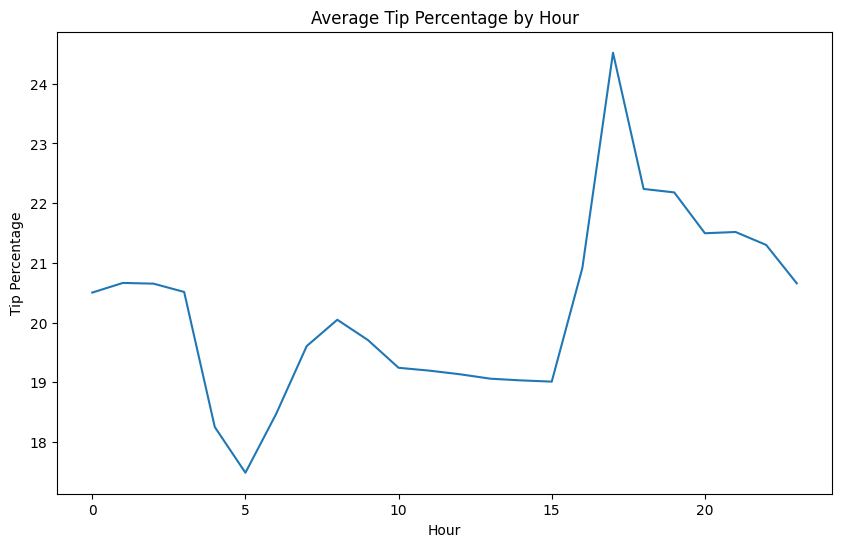

In [101]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
df_tip = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0)
].copy()
df_tip['tip_percentage'] = (
    df_tip['tip_amount'] / df_tip['fare_amount']
) * 100
def distance_tier(distance):
    if distance <= 2:
        return 'Up to 2 miles'
    elif distance <= 5:
        return '2 to 5 miles'
    else:
        return 'More than 5 miles'

df_tip['distance_tier'] = df_tip['trip_distance'].apply(distance_tier)
tip_by_distance = df_tip.groupby('distance_tier').agg(
    avg_tip_percentage=('tip_percentage', 'mean')
).reset_index()

tip_by_distance

tip_by_passenger = df_tip.groupby('passenger_count').agg(
    avg_tip_percentage=('tip_percentage', 'mean')
).reset_index()

tip_by_passenger
tip_by_hour = df_tip.groupby('pickup_hour').agg(
    avg_tip_percentage=('tip_percentage', 'mean')
).reset_index()


plt.figure(figsize=(10,6))
plt.plot(tip_by_hour['pickup_hour'], tip_by_hour['avg_tip_percentage'])
plt.title("Average Tip Percentage by Hour")
plt.xlabel("Hour")
plt.ylabel("Tip Percentage")
plt.show()

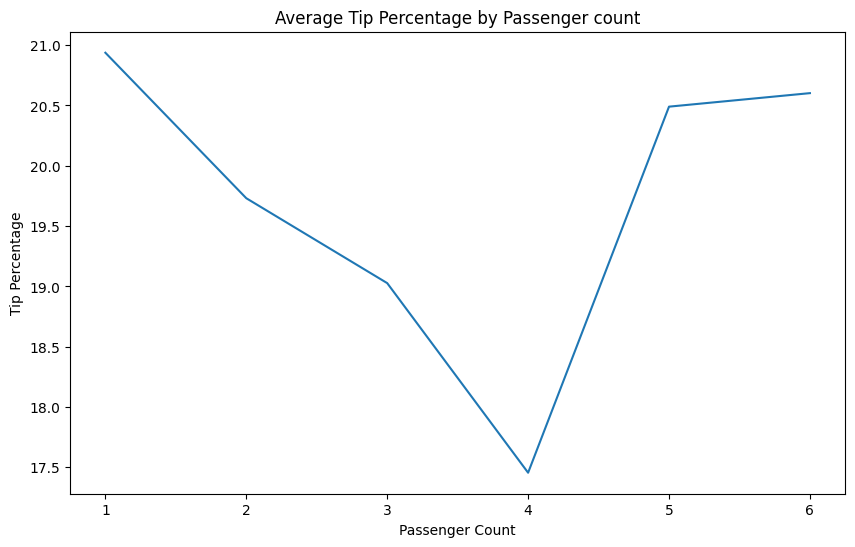

In [102]:
plt.figure(figsize=(10,6))
plt.plot(tip_by_passenger['passenger_count'], tip_by_passenger['avg_tip_percentage'])
plt.title("Average Tip Percentage by Passenger count")
plt.xlabel("Passenger Count")
plt.ylabel("Tip Percentage")
plt.show()

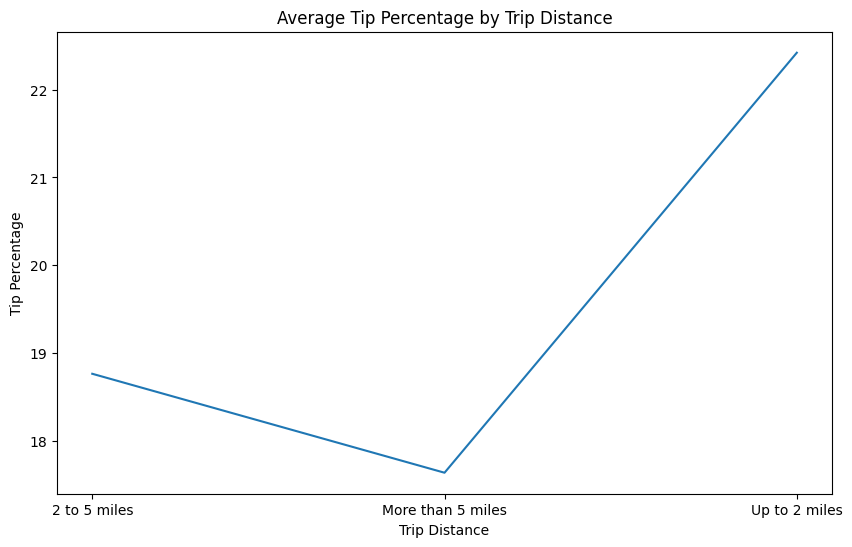

In [104]:
plt.figure(figsize=(10,6))
plt.plot(tip_by_distance['distance_tier'], tip_by_distance['avg_tip_percentage'])
plt.title("Average Tip Percentage by Trip Distance")
plt.xlabel("Trip Distance")
plt.ylabel("Tip Percentage")
plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [105]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
df_tip = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0)
].copy()

df_tip['tip_percentage'] = (
    df_tip['tip_amount'] / df_tip['fare_amount']
) * 100
low_tip = df_tip[df_tip['tip_percentage'] < 10]
high_tip = df_tip[df_tip['tip_percentage'] > 25]
low_tip['trip_distance'].mean()
high_tip['trip_distance'].mean()

low_tip['fare_amount'].mean()
high_tip['fare_amount'].mean()

#low_tip['trip_duration'].mean()
#high_tip['trip_duration'].mean()

low_tip['passenger_count'].mean()
high_tip['passenger_count'].mean()

low_tip.groupby('pickupHr').size()
high_tip.groupby('pickupHr').size()

low_tip['payment_type'].value_counts(normalize=True)
high_tip['payment_type'].value_counts(normalize=True)





,proportion
payment_type,
1,0.999962
2,0.000021
4,0.000014
3,0.000004


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

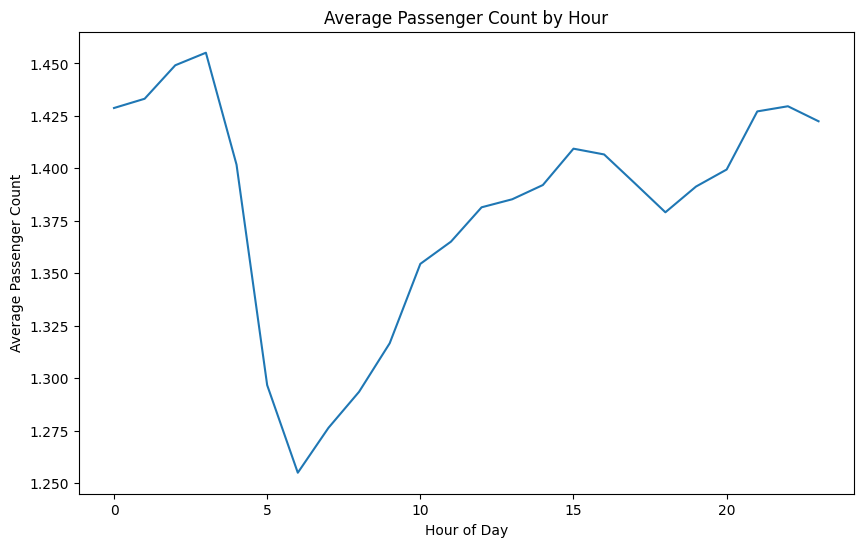

In [106]:
# See how passenger count varies across hours and days
df_pass = df[
    (df['passenger_count'] > 0) &
    (df['passenger_count'] <= 6)
].copy()
passenger_by_hour = df_pass.groupby('pickup_hour').agg(
    avg_passenger_count=('passenger_count', 'mean')
).reset_index()

passenger_by_hour

plt.figure(figsize=(10,6))
plt.plot(passenger_by_hour['pickup_hour'],
         passenger_by_hour['avg_passenger_count'])

plt.title("Average Passenger Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Passenger Count")
plt.show()



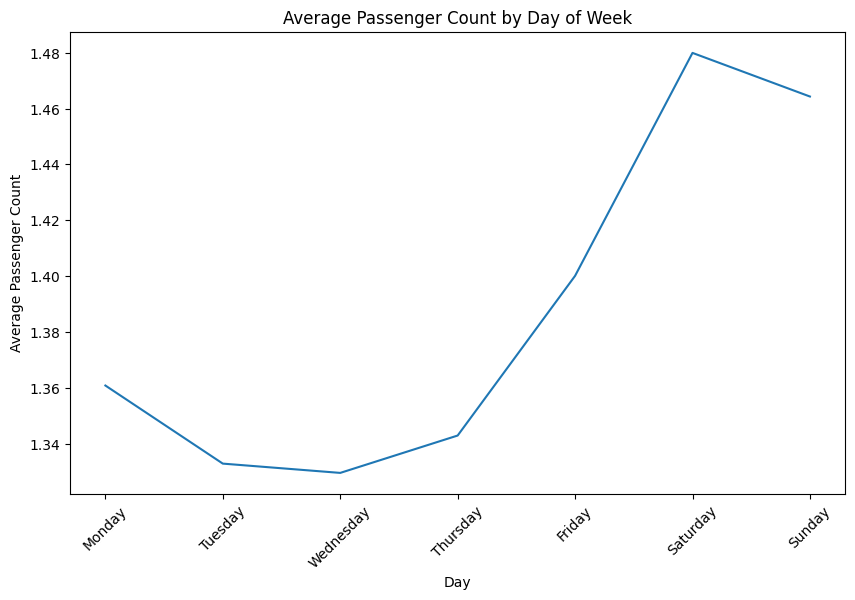

In [107]:
df_pass['pickup_day'] = df_pass['tpep_pickup_datetime'].dt.day_name()
passenger_by_day = df_pass.groupby('pickup_day').agg(
    avg_passenger_count=('passenger_count', 'mean')
).reset_index()
day_order = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']

passenger_by_day['pickup_day'] = pd.Categorical(
    passenger_by_day['pickup_day'],
    categories=day_order,
    ordered=True
)

passenger_by_day = passenger_by_day.sort_values('pickup_day')
plt.figure(figsize=(10,6))
plt.plot(passenger_by_day['pickup_day'],
         passenger_by_day['avg_passenger_count'])

plt.title("Average Passenger Count by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Passenger Count")
plt.xticks(rotation=45)
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

<Axes: >

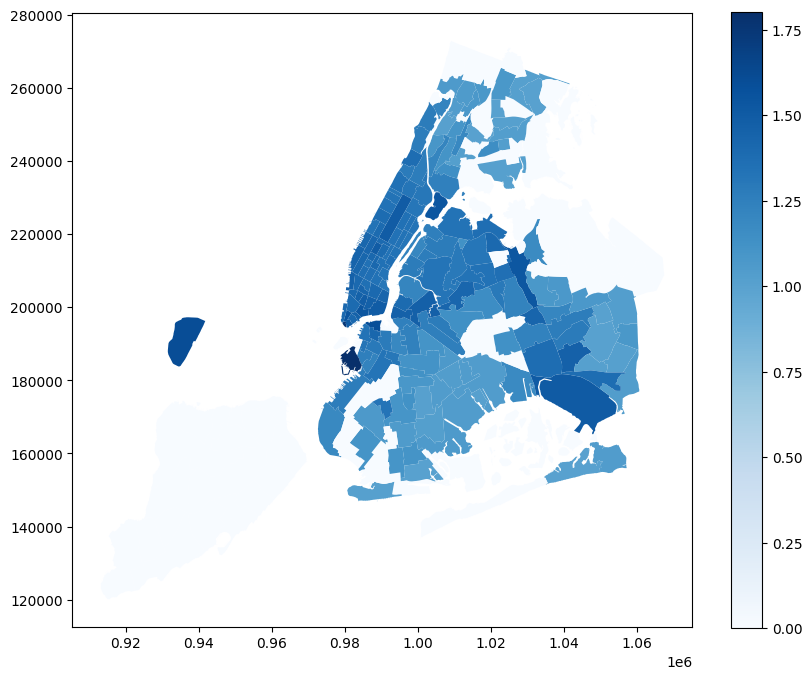

In [108]:
# How does passenger count vary across zones
df_zone_pass = df[
    (df['passenger_count'] > 0) &
    (df['passenger_count'] <= 6)
].copy()
passenger_by_zone = df_zone_pass.groupby('PULocationID').agg(
    avg_passenger_count=('passenger_count', 'mean'),
    trip_count=('passenger_count', 'size')
).reset_index()
passenger_by_zone = passenger_by_zone[
    passenger_by_zone['trip_count'] >= 50
]
passenger_by_zone = passenger_by_zone.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)
passenger_by_zone.sort_values(
    by='avg_passenger_count',
    ascending=False
).head(10)
passenger_by_zone.sort_values(
    by='avg_passenger_count',
    ascending=True
).head(10)

zones_passenger = zones.merge(
    passenger_by_zone[['PULocationID','avg_passenger_count']],
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
)

zones_passenger['avg_passenger_count'] = \
    zones_passenger['avg_passenger_count'].fillna(0)

zones_passenger.plot(
    column='avg_passenger_count',
    cmap='Blues',
    legend=True,
    figsize=(10,8)
)

In [109]:
zones_with_trip_counts.drop(columns=['PULocationID'], inplace=True)
zones_with_trip_counts

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,tripCount
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",214
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",40
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",1861
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",13
...,...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ...",47
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ...",359
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19...",9608
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824....",23617


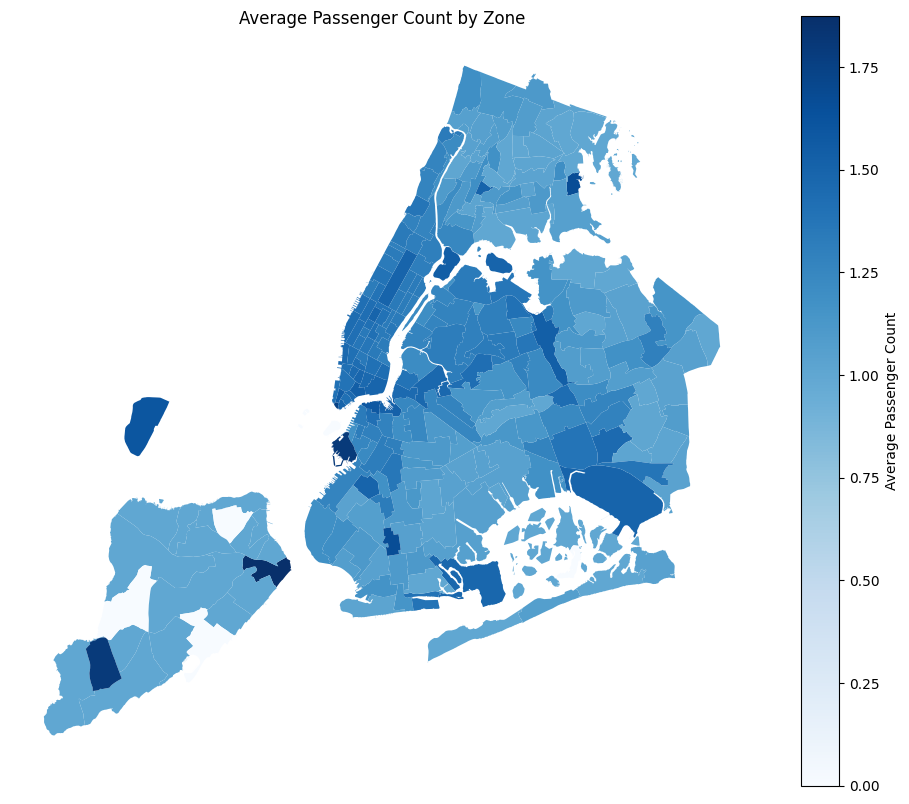

In [110]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

avg_passenger_zone = df[
    (df['passenger_count'] > 0) &
    (df['passenger_count'] <= 6)
].groupby('PULocationID').agg(
    avg_passenger_count=('passenger_count', 'mean')
).reset_index()

zones_with_trip_counts = zones_with_trip_counts.merge(
    avg_passenger_zone,
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
)
zones_with_trip_counts = zones_with_trip_counts.drop(columns=['PULocationID'])
zones_with_trip_counts['avg_passenger_count'] =\
zones_with_trip_counts['avg_passenger_count'].fillna(0)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones_with_trip_counts.plot(
    column='avg_passenger_count',
    cmap='Blues',
    legend=True,
    ax=ax,
    legend_kwds={'label': "Average Passenger Count"}
)

ax.set_title("Average Passenger Count by Zone")
ax.axis('off')

plt.show()


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

/tmp/ipython-input-2144585801.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  extra_by_hour = df.groupby('pickupHr').apply(


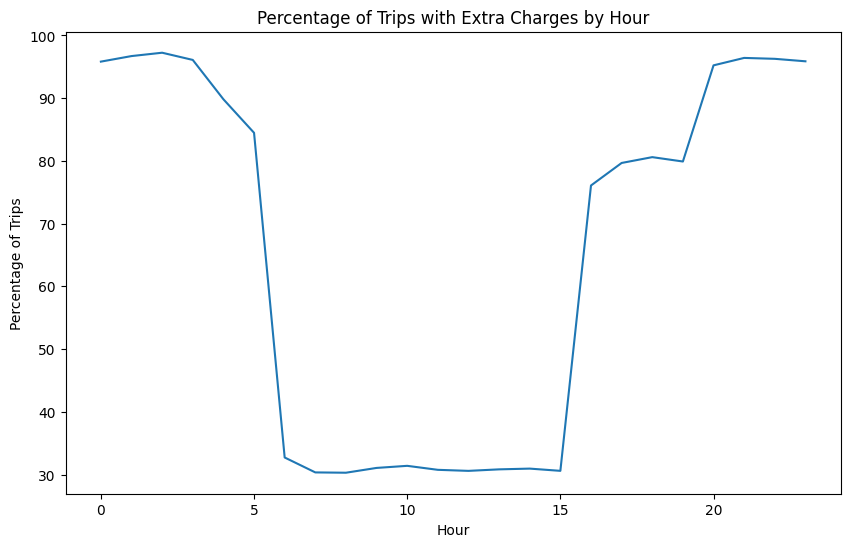

In [111]:
# How often is each surcharge applied?
surcharge_columns = [
    'extra',
    'mta_tax',
    'improvement_surcharge',
    'congestion_surcharge',
    'Airport_fee'
]

surcharge_frequency = {}

for col in surcharge_columns:
    surcharge_frequency[col] = (
        (df[col] > 0).mean() * 100
    )

surcharge_frequency
extra_by_hour = df.groupby('pickupHr').apply(
    lambda x: (x['extra'] > 0).mean() * 100
).reset_index(name='extra_percentage')

extra_by_hour
plt.figure(figsize=(10,6))
plt.plot(extra_by_hour['pickupHr'],
         extra_by_hour['extra_percentage'])

plt.title("Percentage of Trips with Extra Charges by Hour")
plt.xlabel("Hour")
plt.ylabel("Percentage of Trips")
plt.show()


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [ ]:
# 1. Use congestion-aware routing during peak hours to avoid slow routes.
# 2. Increase fleet availability during weekday commute peaks (7-9 AM, 4-7 PM).
# 3. Increase fleet allocation during weekend late-night hours.
# 4. Reposition idle vehicles toward zones with high pickup/dropoff imbalance.
# 5. Maintain dedicated fleet presence in airport zones.
# 6. Use historical hourly trends to predict demand spikes and pre-dispatch vehicles.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [ ]:
# 1. Business District Strategy:
#    - Position more cabs in commercial hubs during weekday mornings.
#    - Shift fleet toward residential zones in the evening.

# 2. Weekend Strategy:
#    - Allocate more cabs to entertainment and nightlife zones.
#    - Increase availability between 10 PM–2 AM on weekends.

# 3. Airport Strategy:
#    - Maintain steady supply near airport zones.
#    - Adjust fleet allocation based on arrival/departure schedules.

# 4. Low-Demand Zones:
#    - Avoid oversupply in zones with consistently low trip counts.
#    - Use dynamic rebalancing instead of static allocation.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [ ]:
# 1. Distance-Based Tier Pricing:
#    - Since short trips have higher fare per mile,
#      review base fare structure for ultra-short trips.
#    - Offer incentives or discounts for longer-distance trips.

# 2. Night-Time Pricing:
#    - Apply mild dynamic pricing during high-demand night hours.
#    - Offer driver incentives instead of steep passenger surcharges.

# 3. Congestion-Based Pricing:
#    - Introduce congestion-adjusted pricing during peak slow hours.
#    - Consider transparent route-based fare breakdown.

# 4. Payment & Tipping Strategy:
#    - Encourage digital payments to increase recorded tip percentages.
#    - Provide preset tip suggestions to improve driver earnings.
#    - Offer loyalty incentives for high-frequency riders.

# 5. Vendor Competitiveness:
#    - Monitor fare per mile differences across vendors.
#    - Adjust pricing in high-competition zones to retain customers.

In [ ]:
# Final Strategic Conclusion:

# Taxi demand is strongly influenced by:
# - Time of day (commute vs leisure)
# - Day of week (weekday vs weekend)
# - Zone type (business, residential, airport)
# - Trip distance
# - Passenger composition
# - Payment behavior

# An optimized strategy should:
# - Dynamically allocate fleet based on temporal demand.
# - Rebalance vehicles using pickup/dropoff ratios.
# - Implement tiered and time-aware pricing strategies.
# - Improve routing efficiency during congestion.
# - Leverage data insights for continuous demand forecasting.

# This integrated approach will maximize revenue,
# improve operational efficiency,
# and enhance customer experience while maintaining competitiveness.